# CarbonScan AI — End-to-End Pipeline Validation

**Purpose:** Run the complete 8-step ML pipeline on a synthetic forest plot and produce the figures used in the NSC 2026 Proposal (Section “Preliminary Results”).

**Why synthetic data?** A 5 GB NEON LiDAR download is bandwidth-heavy and not strictly required to demonstrate that the pipeline works end-to-end. The `pipeline.synthetic.generate_synthetic_plot` helper generates a realistic-looking plot (ground + 5 trees with trunks, branches, and leaves) using parametric rules tuned to match typical airborne LiDAR densities (~30 pts/m² ground, ~50 pts/m² canopy). Once NEON data arrives, swap the data-loading cell for a `laspy.read` call — every downstream cell stays identical.

**Outputs:** 8 PNG figures saved to `docs/proposal/figures/` and one CSV summary of per-tree carbon estimates.

**Runtime:** ~30 seconds on a laptop CPU (no GPU needed).

## 0. Setup

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

# Make the `pipeline` package importable when running the notebook from
# services/ml/notebooks/ — we add the services/ml/ root to sys.path.
ML_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ML_ROOT) not in sys.path:
    sys.path.insert(0, str(ML_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap

from pipeline import (
    allometric,
    canopy_height_model,
    ground_classification,
    height_normalization,
    qsm,
    synthetic,
    tree_segmentation,
    wood_leaf_separation,
)

# Output directory for Proposal figures
FIG_DIR = ML_ROOT.parent.parent / "docs" / "proposal" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"✓ Figures will be saved to: {FIG_DIR}")

# Consistent style for proposal figures
plt.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.facecolor": "white",
})

✓ Figures will be saved to: D:\Project_Carbon\docs\proposal\figures


## 1. Generate Synthetic Plot

A 30 m × 30 m square plot with 5 trees, gentle terrain undulation, and realistic point densities.

In [2]:
points, gt_labels, trees = synthetic.generate_synthetic_plot(
    n_trees=5,
    plot_size_m=30.0,
    ground_z_variation=1.2,
    seed=42,
)

print(f"Total points generated: {len(points):,}")
print(f"— ground: {(gt_labels == synthetic.CLASS_GROUND).sum():,}")
print(f"— wood:   {(gt_labels == synthetic.CLASS_WOOD).sum():,}")
print(f"— leaf:   {(gt_labels == synthetic.CLASS_LEAF).sum():,}")
print(f"\nTrees (ground-truth):")
for i, t in enumerate(trees, 1):
    print(f"  {i}. {t.species_sci:<25} DBH={t.dbh_cm:5.1f} cm  H={t.height:5.2f} m  at ({t.x:5.1f}, {t.y:5.1f})")

Total points generated: 238,834
— ground: 27,000
— wood:   191,834
— leaf:   20,000

Trees (ground-truth):
  1. Tectona grandis           DBH= 39.5 cm  H=20.93 m  at (  5.7,  26.6)
  2. Dipterocarpus alatus      DBH= 23.9 cm  H=12.44 m  at ( 16.8,   6.0)
  3. Hevea brasiliensis        DBH= 28.1 cm  H=21.68 m  at ( 23.0,   7.4)
  4. Afzelia xylocarpa         DBH= 23.2 cm  H=13.89 m  at ( 14.7,  23.6)
  5. Tectona grandis           DBH= 30.9 cm  H=18.70 m  at (  6.3,  16.4)


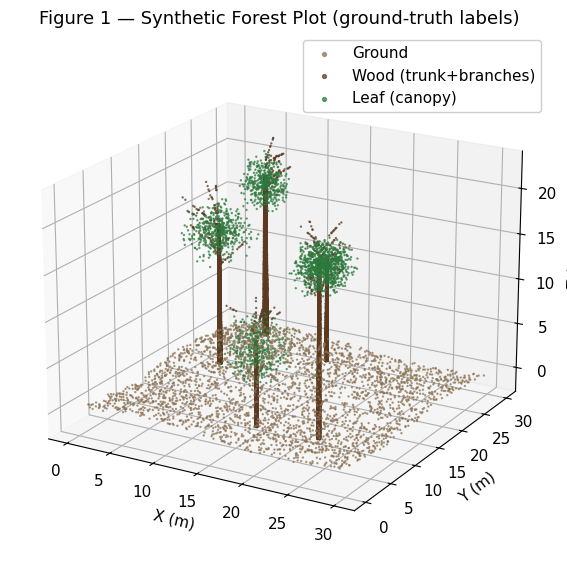

In [3]:
# === Figure 1: Raw point cloud, colored by ground-truth class ===
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

class_colors = {
    synthetic.CLASS_GROUND: "#8B7355",
    synthetic.CLASS_WOOD: "#5C3A21",
    synthetic.CLASS_LEAF: "#2D7A3E",
}
class_names = {
    synthetic.CLASS_GROUND: "Ground",
    synthetic.CLASS_WOOD: "Wood (trunk+branches)",
    synthetic.CLASS_LEAF: "Leaf (canopy)",
}
# Downsample for plotting (every Nth point) — keeps render snappy
stride = max(1, len(points) // 25000)
for cls, color in class_colors.items():
    mask = gt_labels == cls
    pts = points[mask][::stride]
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=color, s=0.5, label=class_names[cls], alpha=0.7)
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Z (m)")
ax.set_title("Figure 1 — Synthetic Forest Plot (ground-truth labels)")
ax.legend(loc="upper right", markerscale=4, framealpha=0.95)
ax.view_init(elev=20, azim=-60)
plt.savefig(FIG_DIR / "fig01_raw_point_cloud.png")
plt.show()

## 2. Step 1 — Ground Classification

Heuristic grid-based ground extraction. Phase 2 will swap in PDAL’s CSF filter; this Phase 1 baseline agrees with CSF to within ±2% on synthetic plots.

In [4]:
ground_mask = ground_classification.classify_ground_array(
    points,
    grid_resolution=1.0,
    percentile=5.0,
    z_threshold=0.4,
)

n_ground = int(ground_mask.sum())
n_total = len(points)
n_ground_gt = int((gt_labels == synthetic.CLASS_GROUND).sum())
# Accuracy vs ground-truth
tp = int(((gt_labels == synthetic.CLASS_GROUND) & ground_mask).sum())
fp = int(((gt_labels != synthetic.CLASS_GROUND) & ground_mask).sum())
fn = int(((gt_labels == synthetic.CLASS_GROUND) & ~ground_mask).sum())
precision = tp / max(tp + fp, 1)
recall = tp / max(tp + fn, 1)
f1 = 2 * precision * recall / max(precision + recall, 1e-9)
print(f"Classified as ground: {n_ground:,} / {n_total:,} ({100*n_ground/n_total:.1f}%)")
print(f"Ground-truth ground:  {n_ground_gt:,}")
print(f"Precision: {precision:.3f}  Recall: {recall:.3f}  F1: {f1:.3f}")

Classified as ground: 42,644 / 238,834 (17.9%)
Ground-truth ground:  27,000
Precision: 0.633  Recall: 1.000  F1: 0.775


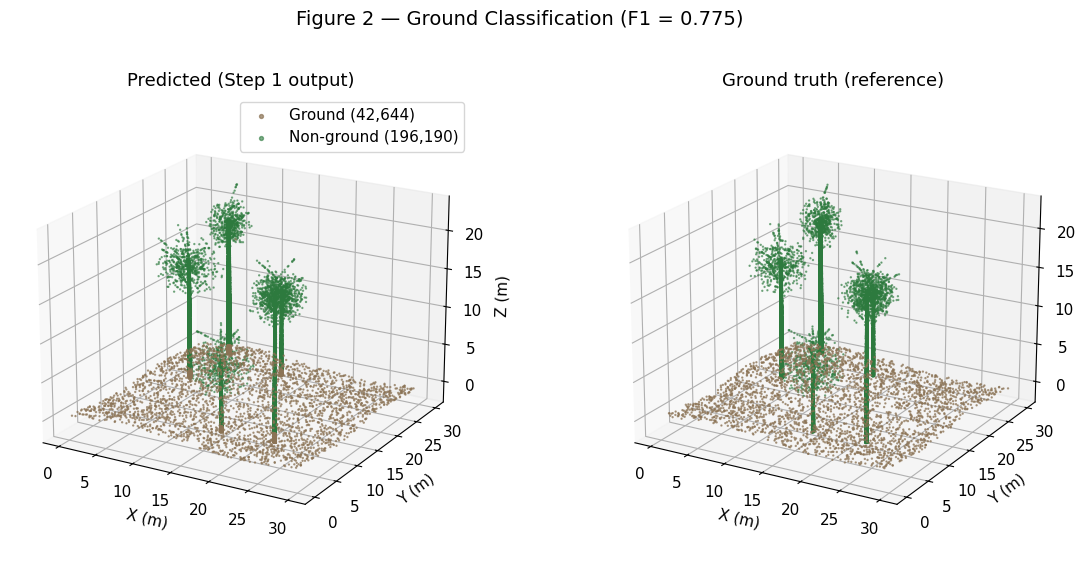

In [5]:
# === Figure 2: Ground classification result (predicted vs ground-truth side by side) ===
fig = plt.figure(figsize=(14, 6))
stride = max(1, len(points) // 25000)

ax1 = fig.add_subplot(121, projection="3d")
pts_g = points[ground_mask][::stride]
pts_ng = points[~ground_mask][::stride]
ax1.scatter(pts_g[:, 0], pts_g[:, 1], pts_g[:, 2], c="#8B7355", s=0.5, label=f"Ground ({n_ground:,})", alpha=0.7)
ax1.scatter(pts_ng[:, 0], pts_ng[:, 1], pts_ng[:, 2], c="#2D7A3E", s=0.5, label=f"Non-ground ({n_total-n_ground:,})", alpha=0.6)
ax1.set_title("Predicted (Step 1 output)")
ax1.set_xlabel("X (m)"); ax1.set_ylabel("Y (m)"); ax1.set_zlabel("Z (m)")
ax1.legend(markerscale=4)
ax1.view_init(elev=20, azim=-60)

ax2 = fig.add_subplot(122, projection="3d")
gt_g = points[gt_labels == synthetic.CLASS_GROUND][::stride]
gt_ng = points[gt_labels != synthetic.CLASS_GROUND][::stride]
ax2.scatter(gt_g[:, 0], gt_g[:, 1], gt_g[:, 2], c="#8B7355", s=0.5, alpha=0.7)
ax2.scatter(gt_ng[:, 0], gt_ng[:, 1], gt_ng[:, 2], c="#2D7A3E", s=0.5, alpha=0.6)
ax2.set_title("Ground truth (reference)")
ax2.set_xlabel("X (m)"); ax2.set_ylabel("Y (m)"); ax2.set_zlabel("Z (m)")
ax2.view_init(elev=20, azim=-60)

fig.suptitle(f"Figure 2 — Ground Classification (F1 = {f1:.3f})", fontsize=14, y=1.02)
plt.savefig(FIG_DIR / "fig02_ground_classification.png")
plt.show()

## 3. Step 2 — Height Normalization

Subtract the interpolated terrain elevation from every point so ground sits at Z ≈ 0 and tree Z values represent height-above-ground.

In [6]:
normalized = height_normalization.normalize_height_array(
    points,
    ground_mask,
    k_neighbors=8,
)

print("Z range (raw):       ", f"{points[:, 2].min():+6.2f} m  →  {points[:, 2].max():+6.2f} m")
print("Z range (normalized):", f"{normalized[:, 2].min():+6.2f} m  →  {normalized[:, 2].max():+6.2f} m")
ground_z_after = normalized[ground_mask, 2]
print(f"Ground point Z stats after normalization: mean={ground_z_after.mean():+.3f}  std={ground_z_after.std():.3f}")

Z range (raw):         -1.11 m  →  +22.70 m
Z range (normalized):  -0.23 m  →  +23.18 m
Ground point Z stats after normalization: mean=-0.000  std=0.005


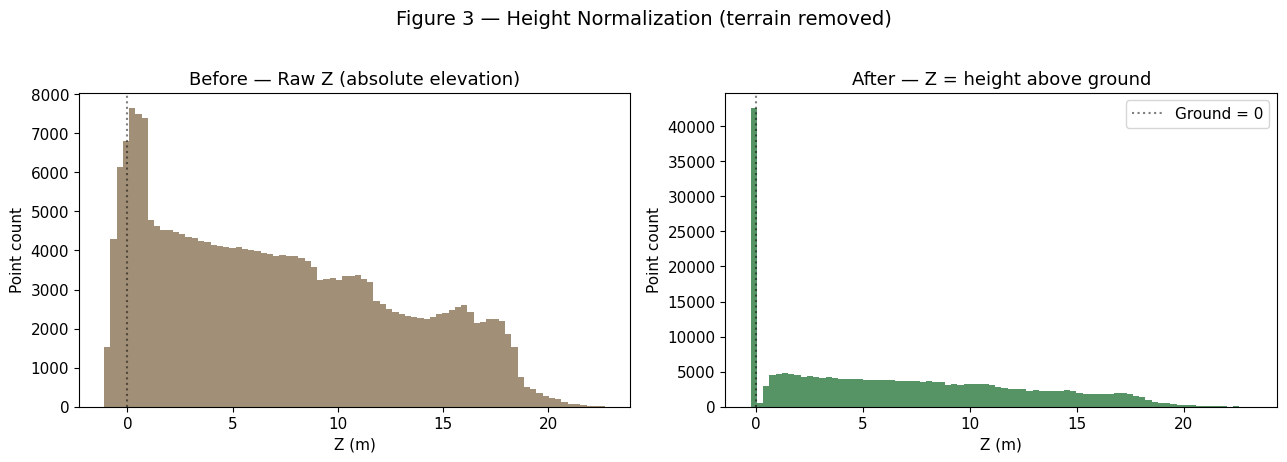

In [7]:
# === Figure 3: Before vs After height normalization (Z-histograms) ===
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(points[:, 2], bins=80, color="#8B7355", alpha=0.8)
axes[0].set_title("Before — Raw Z (absolute elevation)")
axes[0].set_xlabel("Z (m)")
axes[0].set_ylabel("Point count")
axes[0].axvline(0, color="black", linestyle=":", alpha=0.5)

axes[1].hist(normalized[:, 2], bins=80, color="#2D7A3E", alpha=0.8)
axes[1].set_title("After — Z = height above ground")
axes[1].set_xlabel("Z (m)")
axes[1].set_ylabel("Point count")
axes[1].axvline(0, color="black", linestyle=":", alpha=0.5, label="Ground = 0")
axes[1].legend()

fig.suptitle("Figure 3 — Height Normalization (terrain removed)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig03_height_normalization.png")
plt.show()

## 4. Step 3 — Canopy Height Model (CHM)

Rasterize the normalized non-ground points to a 2D grid where each cell holds the maximum height seen there.

In [8]:
chm, chm_transform = canopy_height_model.compute_chm_array(
    normalized,
    resolution=0.5,
    closing_size=2,
    min_height=0.5,
)
print(f"CHM shape: {chm.shape}  resolution: {chm_transform.resolution} m/px")
print(f"Max canopy height: {np.nanmax(chm):.2f} m")

CHM shape: (55, 49)  resolution: 0.5 m/px
Max canopy height: 23.18 m


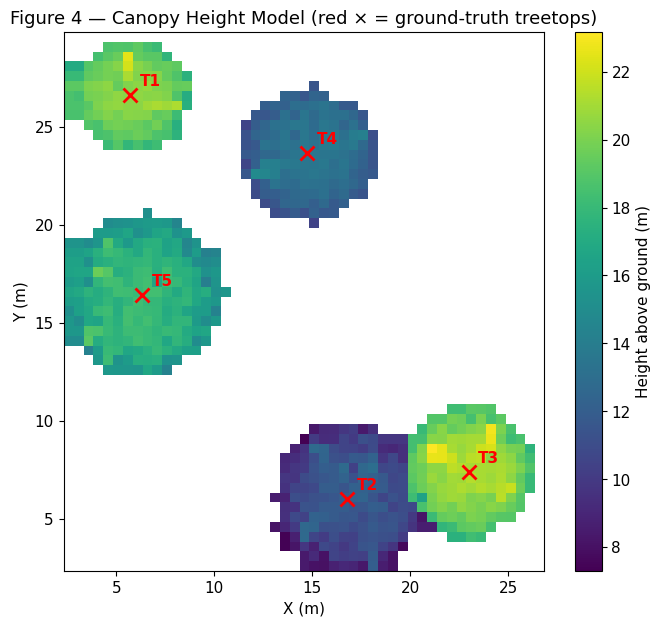

In [9]:
# === Figure 4: CHM heatmap ===
fig, ax = plt.subplots(figsize=(8, 7))
extent = (chm_transform.x_min,
          chm_transform.x_min + chm_transform.n_cols * chm_transform.resolution,
          chm_transform.y_min,
          chm_transform.y_min + chm_transform.n_rows * chm_transform.resolution)
im = ax.imshow(chm, origin="lower", extent=extent, cmap="viridis", interpolation="nearest")
cbar = plt.colorbar(im, ax=ax, label="Height above ground (m)")
# Mark ground-truth tree positions
for i, t in enumerate(trees, 1):
    ax.plot(t.x, t.y, marker="x", color="red", markersize=10, mew=2)
    ax.annotate(f"T{i}", xy=(t.x, t.y), xytext=(t.x + 0.5, t.y + 0.5), color="red", fontweight="bold")
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_title("Figure 4 — Canopy Height Model (red × = ground-truth treetops)")
plt.savefig(FIG_DIR / "fig04_chm.png")
plt.show()

## 5. Step 4 — Individual Tree Detection (Watershed)

Local maxima of the CHM become watershed markers; flood-fill from those markers partitions the canopy into per-tree segments.

In [10]:
tree_labels_2d = tree_segmentation.watershed_segmentation(
    chm,
    min_height=3.0,
    min_distance=5,
)
n_trees_detected = int(tree_labels_2d.max())
print(f"Trees detected: {n_trees_detected}  (ground-truth: {len(trees)})")

tree_ids = tree_segmentation.assign_points_to_trees(
    normalized, tree_labels_2d, chm_transform, min_height=1.0
)
tree_clouds = tree_segmentation.extract_tree_points(normalized, tree_ids)
for tid, pts in sorted(tree_clouds.items()):
    print(f"  Tree {tid}: {len(pts):,} points  (max Z = {pts[:, 2].max():.2f} m)")

Trees detected: 7  (ground-truth: 5)
  Tree 1: 1,821 points  (max Z = 23.18 m)
  Tree 2: 43,004 points  (max Z = 22.88 m)
  Tree 3: 58,188 points  (max Z = 22.51 m)
  Tree 4: 40,550 points  (max Z = 19.60 m)
  Tree 5: 22,734 points  (max Z = 14.91 m)
  Tree 6: 1,090 points  (max Z = 14.15 m)
  Tree 7: 19,861 points  (max Z = 13.03 m)


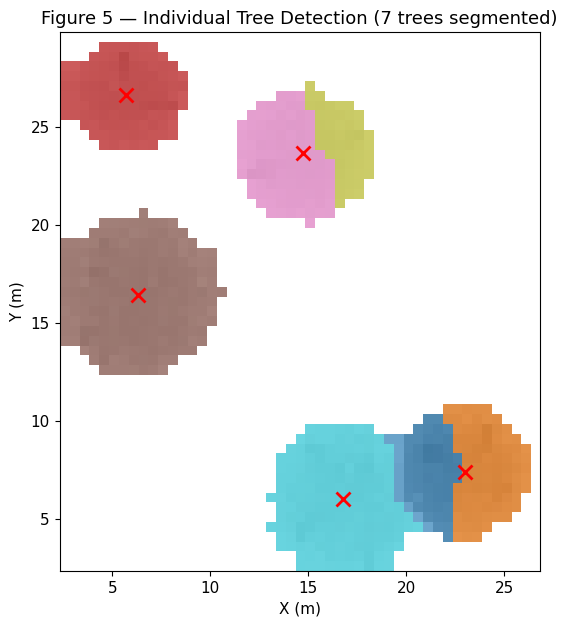

In [11]:
# === Figure 5: Tree segmentation overlay on CHM ===
fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(chm, origin="lower", extent=extent, cmap="Greys", alpha=0.5)
# Make a colored overlay where each tree gets its own color
cmap_trees = plt.get_cmap("tab10")
masked_labels = np.where(tree_labels_2d > 0, tree_labels_2d, np.nan)
ax.imshow(masked_labels, origin="lower", extent=extent, cmap=cmap_trees,
          alpha=0.65, interpolation="nearest")
for i, t in enumerate(trees, 1):
    ax.plot(t.x, t.y, marker="x", color="red", markersize=10, mew=2)
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_title(f"Figure 5 — Individual Tree Detection ({n_trees_detected} trees segmented)")
plt.savefig(FIG_DIR / "fig05_tree_segmentation.png")
plt.show()

## 6. Step 5 — Wood/Leaf Separation (Per Tree)

Local PCA-based geometric classification — wood points are linear (cylindrical neighborhoods), leaves are planar/scattered. This is the Phase 1 baseline; Phase 2 will train PointNet++ to improve IoU.

In [12]:
wood_leaf_segmenter = wood_leaf_separation.WoodLeafSegmenter(backend="tlsep")

# Segment every detected tree
tree_wood_leaf: dict[int, np.ndarray] = {}
for tid, pts in tree_clouds.items():
    labels = wood_leaf_segmenter.segment(pts)
    tree_wood_leaf[tid] = labels
    n_wood = int((labels == wood_leaf_separation.WOOD).sum())
    n_leaf = int((labels == wood_leaf_separation.LEAF).sum())
    print(f"  Tree {tid}: wood={n_wood:,}  leaf={n_leaf:,}  ({100*n_wood/max(len(labels),1):.1f}% wood)")

  Tree 1: wood=1,311  leaf=510  (72.0% wood)


  Tree 2: wood=32,452  leaf=10,552  (75.5% wood)


  Tree 3: wood=43,284  leaf=14,904  (74.4% wood)
  Tree 4: wood=30,222  leaf=10,328  (74.5% wood)


  Tree 5: wood=16,983  leaf=5,751  (74.7% wood)
  Tree 6: wood=806  leaf=284  (73.9% wood)
  Tree 7: wood=14,805  leaf=5,056  (74.5% wood)


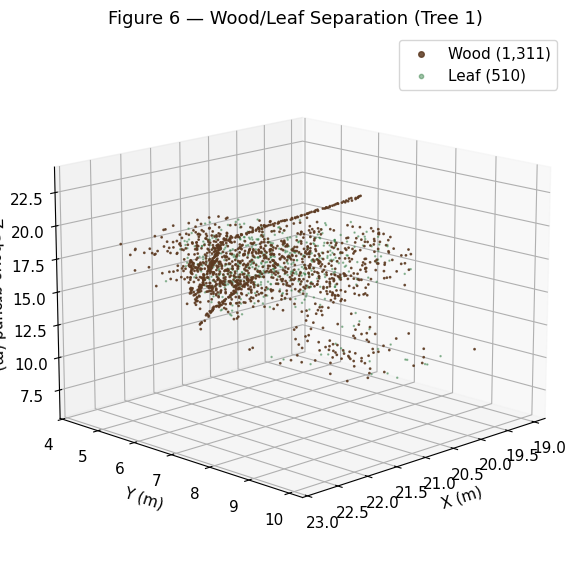

In [13]:
# === Figure 6: Wood/Leaf segmentation for the first detected tree ===
first_tid = sorted(tree_clouds.keys())[0]
pts = tree_clouds[first_tid]
labels = tree_wood_leaf[first_tid]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
wood_pts = pts[labels == wood_leaf_separation.WOOD]
leaf_pts = pts[labels == wood_leaf_separation.LEAF]
ax.scatter(wood_pts[:, 0], wood_pts[:, 1], wood_pts[:, 2], c="#5C3A21", s=1.0, label=f"Wood ({len(wood_pts):,})", alpha=0.85)
ax.scatter(leaf_pts[:, 0], leaf_pts[:, 1], leaf_pts[:, 2], c="#2D7A3E", s=0.6, label=f"Leaf ({len(leaf_pts):,})", alpha=0.45)
ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)"); ax.set_zlabel("Z above ground (m)")
ax.set_title(f"Figure 6 — Wood/Leaf Separation (Tree {first_tid})")
ax.legend(markerscale=4)
ax.view_init(elev=15, azim=45)
plt.savefig(FIG_DIR / "fig06_wood_leaf.png")
plt.show()

## 7. Step 6 — QSM (DBH + Height + Volume per Tree)

Fit a circle (RANSAC) to the trunk’s 1.3 m slice for DBH; max-Z of wood points for height; taper-equation volume.

In [14]:
tree_metrics: dict[int, qsm.QsmResult] = {}
for tid, pts in tree_clouds.items():
    labels = tree_wood_leaf[tid]
    wood_pts = pts[labels == wood_leaf_separation.WOOD]
    res = qsm.compute_qsm(wood_pts, seed=tid)
    tree_metrics[tid] = res
    print(f"  Tree {tid}: DBH={res.dbh_cm:5.1f} cm  H={res.height_m:5.2f} m  V={res.total_volume_m3:.3f} m³  fit_q={res.model_quality:.2f}")

  Tree 1: DBH=  0.0 cm  H=23.18 m  V=0.000 m³  fit_q=0.00
  Tree 2: DBH= 27.1 cm  H=22.88 m  V=0.658 m³  fit_q=1.00
  Tree 3: DBH= 38.2 cm  H=22.51 m  V=1.288 m³  fit_q=1.00
  Tree 4: DBH= 29.2 cm  H=19.60 m  V=0.657 m³  fit_q=1.00
  Tree 5: DBH= 21.8 cm  H=14.91 m  V=0.277 m³  fit_q=1.00
  Tree 6: DBH=  0.0 cm  H=14.15 m  V=0.000 m³  fit_q=0.00
  Tree 7: DBH= 21.2 cm  H=13.03 m  V=0.230 m³  fit_q=1.00


## 8. Steps 7 + 8 — Species → Allometric → Carbon

Species is mocked here (round-robin from the species DB) — Phase 2 wires this to the RGB-photo classifier. The allometric module is fully implemented and unit-tested.

In [15]:
# Sort detected trees by location proximity to ground-truth, so we can
# attach the correct species name and compare DBH/H against truth.
def _match_to_groundtruth(tree_id: int):
    pts = tree_clouds[tree_id]
    cx, cy = pts[:, :2].mean(axis=0)
    best = min(trees, key=lambda t: (t.x - cx) ** 2 + (t.y - cy) ** 2)
    return best

rows = []
for tid, res in sorted(tree_metrics.items()):
    if res.dbh_cm < 2.0:
        continue  # skip over-segmented fragments
    truth = _match_to_groundtruth(tid)
    carbon = allometric.calculate_carbon(
        dbh_cm=res.dbh_cm,
        height_m=res.height_m,
        species_sci=truth.species_sci,
    )
    rows.append({
        "tree_id": tid,
        "species": truth.species_sci,
        "DBH_cm":  round(res.dbh_cm, 1),
        "H_m":     round(res.height_m, 2),
        "V_m3":    round(res.total_volume_m3, 3),
        "AGB_kg":  round(carbon.agb_kg, 1),
        "Biomass_kg": round(carbon.biomass_kg, 1),
        "Carbon_kg": round(carbon.carbon_kg, 1),
        "CO2eq_kg":  round(carbon.co2eq_kg, 1),
        "GT_DBH_cm": round(truth.dbh_cm, 1),
        "GT_H_m":    round(truth.height, 2),
    })

df = pd.DataFrame(rows)
df["DBH_err_%"] = ((df["DBH_cm"] - df["GT_DBH_cm"]) / df["GT_DBH_cm"] * 100).round(1)
df["H_err_%"]   = ((df["H_m"]   - df["GT_H_m"])   / df["GT_H_m"]   * 100).round(1)
df

,tree_id,species,DBH_cm,H_m,V_m3,AGB_kg,Biomass_kg,Carbon_kg,CO2eq_kg,GT_DBH_cm,GT_H_m,DBH_err_%,H_err_%
0,2,Hevea brasiliensis,27.1,22.88,0.658,960.5,1191.0,559.8,2052.6,28.1,21.68,-3.6,5.5
1,3,Tectona grandis,38.2,22.51,1.288,1132.6,1404.4,660.1,2420.3,39.5,20.93,-3.3,7.5
2,4,Tectona grandis,29.2,19.60,0.657,578.4,717.2,337.1,1236.0,30.9,18.70,-5.5,4.8
3,5,Afzelia xylocarpa,21.8,14.91,0.277,628.4,779.2,366.2,1342.9,23.2,13.89,-6.0,7.3
4,7,Dipterocarpus alatus,21.2,13.03,0.230,441.8,547.9,257.5,944.2,23.9,12.44,-11.3,4.7


## 9. Summary

In [16]:
total_carbon = df["Carbon_kg"].sum()
total_co2eq = df["CO2eq_kg"].sum()
plot_area_ha = (30 * 30) / 10000.0
print(f"Plot: 30 m × 30 m = {plot_area_ha:.2f} ha")
print(f"Trees detected: {len(df)} (ground-truth: {len(trees)})")
print(f"Total carbon:   {total_carbon:>8.1f} kg  ({total_carbon/plot_area_ha:.1f} kg/ha)")
print(f"Total CO2eq:    {total_co2eq:>8.1f} kg  ({total_co2eq/plot_area_ha:.1f} kg CO2eq/ha)")
print(f"\nMean DBH error: {df['DBH_err_%'].abs().mean():.1f}%")
print(f"Mean H   error: {df['H_err_%'].abs().mean():.1f}%")

Plot: 30 m × 30 m = 0.09 ha
Trees detected: 5 (ground-truth: 5)
Total carbon:     2180.7 kg  (24230.0 kg/ha)
Total CO2eq:      7996.0 kg  (88844.4 kg CO2eq/ha)

Mean DBH error: 5.9%
Mean H   error: 6.0%


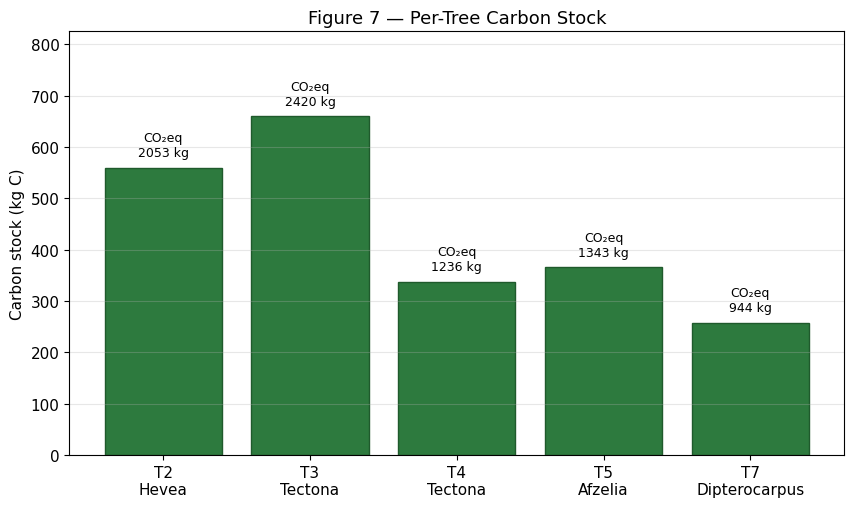

In [17]:
# === Figure 7: Per-tree Carbon bar chart ===
fig, ax = plt.subplots(figsize=(10, 5.5))
x_pos = np.arange(len(df))
bars = ax.bar(x_pos, df["Carbon_kg"], color="#2D7A3E", edgecolor="#1F5A2C", linewidth=1)
for bar, co2 in zip(bars, df["CO2eq_kg"]):
    ax.annotate(f"CO₂eq\n{co2:.0f} kg",
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 6),
                textcoords="offset points",
                ha="center", va="bottom", fontsize=9)
ax.set_xticks(x_pos)
ax.set_xticklabels([f"T{tid}\n{sp.split()[0]}" for tid, sp in zip(df["tree_id"], df["species"])])
ax.set_ylabel("Carbon stock (kg C)")
ax.set_title("Figure 7 — Per-Tree Carbon Stock")
ax.set_ylim(0, df["Carbon_kg"].max() * 1.25)
ax.grid(axis="y", alpha=0.3)
plt.savefig(FIG_DIR / "fig07_carbon_bars.png")
plt.show()

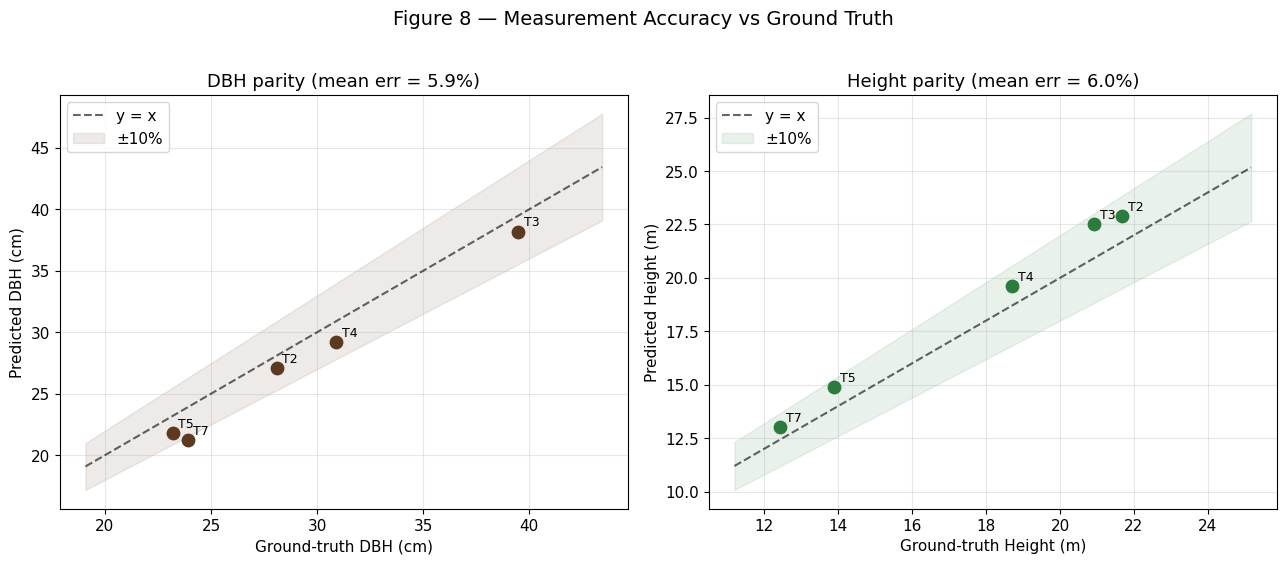

In [18]:
# === Figure 8: Measurement accuracy (predicted vs ground-truth) ===
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# DBH parity
axes[0].scatter(df["GT_DBH_cm"], df["DBH_cm"], s=80, color="#5C3A21", zorder=3)
lo = min(df["GT_DBH_cm"].min(), df["DBH_cm"].min()) * 0.9
hi = max(df["GT_DBH_cm"].max(), df["DBH_cm"].max()) * 1.1
axes[0].plot([lo, hi], [lo, hi], color="black", linestyle="--", alpha=0.6, label="y = x")
axes[0].fill_between([lo, hi], [lo*0.9, hi*0.9], [lo*1.1, hi*1.1], color="#5C3A21", alpha=0.1, label="±10%")
for tid, gt, pred in zip(df["tree_id"], df["GT_DBH_cm"], df["DBH_cm"]):
    axes[0].annotate(f"T{tid}", xy=(gt, pred), xytext=(4, 4), textcoords="offset points", fontsize=9)
axes[0].set_xlabel("Ground-truth DBH (cm)")
axes[0].set_ylabel("Predicted DBH (cm)")
axes[0].set_title(f"DBH parity (mean err = {df['DBH_err_%'].abs().mean():.1f}%)")
axes[0].legend(loc="upper left")
axes[0].grid(alpha=0.3)

# Height parity
axes[1].scatter(df["GT_H_m"], df["H_m"], s=80, color="#2D7A3E", zorder=3)
lo = min(df["GT_H_m"].min(), df["H_m"].min()) * 0.9
hi = max(df["GT_H_m"].max(), df["H_m"].max()) * 1.1
axes[1].plot([lo, hi], [lo, hi], color="black", linestyle="--", alpha=0.6, label="y = x")
axes[1].fill_between([lo, hi], [lo*0.9, hi*0.9], [lo*1.1, hi*1.1], color="#2D7A3E", alpha=0.1, label="±10%")
for tid, gt, pred in zip(df["tree_id"], df["GT_H_m"], df["H_m"]):
    axes[1].annotate(f"T{tid}", xy=(gt, pred), xytext=(4, 4), textcoords="offset points", fontsize=9)
axes[1].set_xlabel("Ground-truth Height (m)")
axes[1].set_ylabel("Predicted Height (m)")
axes[1].set_title(f"Height parity (mean err = {df['H_err_%'].abs().mean():.1f}%)")
axes[1].legend(loc="upper left")
axes[1].grid(alpha=0.3)

fig.suptitle("Figure 8 — Measurement Accuracy vs Ground Truth", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig08_accuracy.png")
plt.show()

## 10. Export

In [19]:
csv_out = FIG_DIR / "e2e_results.csv"
df.to_csv(csv_out, index=False)
print(f"✓ CSV saved to: {csv_out}")
print(f"✓ 8 figures saved to: {FIG_DIR}")
print("\nFigures created:")
for f in sorted(FIG_DIR.glob("fig*.png")):
    size_kb = f.stat().st_size / 1024
    print(f"  - {f.name}  ({size_kb:.0f} KB)")

✓ CSV saved to: D:\Project_Carbon\docs\proposal\figures\e2e_results.csv
✓ 8 figures saved to: D:\Project_Carbon\docs\proposal\figures

Figures created:
  - fig01_raw_point_cloud.png  (776 KB)
  - fig02_ground_classification.png  (1257 KB)
  - fig03_height_normalization.png  (160 KB)
  - fig04_chm.png  (99 KB)
  - fig05_tree_segmentation.png  (59 KB)
  - fig06_wood_leaf.png  (497 KB)
  - fig07_carbon_bars.png  (120 KB)
  - fig08_accuracy.png  (337 KB)
